# Advanced SBTS Benchmark: Jump-Diffusion & Volatility Purification

This notebook comprehensively compares three methods on real financial data. This comparison integrates **Jump-Diffusion** and **Volatility Purification** techniques.

### Experiment Logic Update:
1. **Jump Detection**: Identify extreme market conditions in historical data.
2. **Data Purification**: Remove jumps to obtain 'clean data'.
3. **Volatility Calibration**: Train Local Volatility on clean data to avoid double counting of variance.
4. **Hybrid Generation**: Superimpose $ \sigma_{clean} dW_t $ (continuous) and $ dJ_t $ (jump) during generation.

### Comparison Models:
*   **Kernel**: Benchmark non-parametric model.
*   **LSTM (Advanced)**: Deep learning model with Drift Dampening.
*   **LightSB**: Lightweight model based on potential functions (with gradient clipping).


In [1]:
import time
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import wasserstein_distance

# Import core modules
from core.solver import euler_maruyama_generator
from core.drift_estimators import KernelDriftEstimator, LSTMDriftEstimator
from core.lightsb import LightSBTrainer 
from core.reference import LocalVolatilityReference, JumpDiffusionReference
from models.calibration import VolatilityCalibrator
from models.jumps import JumpDetector
from utils.data_loader import RealDataLoader, reconstruct_prices
from utils.visualization import set_style, _calc_autocorr

set_style()
print("Environment Ready.")

Environment Ready.


## 1. Data Loading

In [2]:
TICKER = 'SPY'
START = '2020-01-01'
END = '2023-12-31'
SEQ_LEN = 60
DT = 1.0 / 252.0
TIME_GRID = np.linspace(0, SEQ_LEN * DT, SEQ_LEN)

loader = RealDataLoader(TICKER, START, END)
loader.download()
data, mu, sigma = loader.get_sliding_windows(SEQ_LEN)

print(f"Data Shape: {data.shape}")

# Test Set: Last 1000 windows
N_TEST = min(1000, len(data))
test_idx = np.random.choice(len(data), N_TEST, replace=False)
test_x0 = data[test_idx, 0, :]
real_paths_subset = data[test_idx]

   [Data] Downloading SPY from 2020-01-01 to 2023-12-31...


/Users/lizhanhong/X/PSC/codes/SBTS/sbts_advanced/utils/data_loader.py:19: FutureWarning: YF.download() has changed argument auto_adjust default to True
  self.raw_data = yf.download(self.ticker, start=self.start, end=self.end, interval=self.interval, progress=False)


   [Data] Downloaded 1006 data points.
   [Data] Created 946 samples of length 60 from real data.
Data Shape: (946, 60, 1)


## 2. Jump Detection and Data Purification
This is a key step: To prevent the volatility model from mistaking 'jumps' for 'high volatility', we first remove the jumps.

In [3]:
# 1. Detect Jumps
jump_detector = JumpDetector(dt=DT, threshold_multiplier=4.0)
jump_detector.fit(data)

# 2. Data Purification
# Calculate robust sigma for truncation
flat_data = data.flatten()
sigma_robust = np.median(np.abs(flat_data)) / 0.6745
threshold = 4.0 * sigma_robust * np.sqrt(DT)

data_clean = np.clip(data, -threshold, threshold)
print(f"Data clipped to range [{ -threshold:.4f}, {threshold:.4f}] for volatility calibration.")

   [Jumps] Detected 44060 jumps. Intensity (lambda): 195.6152
   [Jumps] Jump Size Dist: N(0.00067, 0.01537)
Data clipped to range [-0.0026, 0.0026] for volatility calibration.


## 3. Volatility Calibration
Note: We use **Clean Data** to train the volatility model.

In [4]:
print("Fitting Volatility Surface on CLEAN data...")
vol_calibrator = VolatilityCalibrator(dt=DT, method='kernel', bandwidth=0.5)
vol_calibrator.fit(data_clean) # <--- Use clean data

Fitting Volatility Surface on CLEAN data...
   [Calibration] Computing realized volatility surface...
   [Calibration] Local Volatility Surface fitted (Normalized).


## 4. Drift Training
The Drift model is still trained on **raw data** to learn the mean reversion response after jumps.

In [5]:
results = {'Kernel': {}, 'LSTM': {}, 'LightSB': {}}

# --- Kernel ---
print("Training Kernel...")
start_t = time.time()
kernel_model = KernelDriftEstimator(bandwidth=0.05)
kernel_model.fit(data, DT)
results['Kernel']['train_time'] = time.time() - start_t

# --- LSTM ---
print("Training LSTM...")
start_t = time.time()
lstm_model = LSTMDriftEstimator(
    hidden_size=128, lr=0.005, epochs=100, 
    weight_decay=1e-3, dropout=0.3, dt=DT
)
lstm_model.fit(data, DT)
results['LSTM']['train_time'] = time.time() - start_t

# --- LightSB ---
print("Training LightSB...")
start_t = time.time()
X_curr = data[:, :-1, :].reshape(-1, 1)
X_next = data[:, 1:, :].reshape(-1, 1)
x0_t = torch.tensor(X_curr, dtype=torch.float32)
x1_t = torch.tensor(X_next, dtype=torch.float32)

lsb_model = LightSBTrainer(dim=1, n_components=20, lr=0.005, min_cov=0.01)
for i in range(500):
    idx = np.random.choice(len(x0_t), 1024)
    lsb_model.train_step(x0_t[idx], x1_t[idx])
results['LightSB']['train_time'] = time.time() - start_t

print("Training Done.")

Training Kernel...
Training LSTM...
   [LSTM] Training start (wd=0.001, drop=0.3)...
Training LightSB...
Training Done.


## 5. Jump-Diffusion Generation
Construct `JumpDiffusionReference`, combining purified volatility with the jump process.

In [6]:
print("Generating Paths (Jump-Diffusion)...")

# --- Kernel Gen ---
start_t = time.time()
# Volatility multiplier slightly larger (1.1) to compensate for removed noise
ref_k = JumpDiffusionReference(vol_calibrator, jump_detector, volatility_multiplier=1.1)
paths_kernel = euler_maruyama_generator(
    test_x0, TIME_GRID, lambda t,x: kernel_model.predict(t,x), ref_k, n_paths=N_TEST
)
results['Kernel']['gen_time'] = time.time() - start_t
results['Kernel']['paths'] = paths_kernel

# --- LSTM Gen ---
start_t = time.time()
# LSTM needs Drift Dampening (0.8)
ref_l = JumpDiffusionReference(vol_calibrator, jump_detector, volatility_multiplier=1.1)
damp = 0.8
paths_lstm = euler_maruyama_generator(
    test_x0, TIME_GRID, lambda t,x: lstm_model.predict(t,x)*damp, ref_l, n_paths=N_TEST
)
results['LSTM']['gen_time'] = time.time() - start_t
results['LSTM']['paths'] = paths_lstm

# --- LightSB Gen ---
start_t = time.time()
ref_sb = JumpDiffusionReference(vol_calibrator, jump_detector, volatility_multiplier=1.1)
def lightsb_drift(t, x): 
    return lsb_model.get_drift(t, x, clip_val=3.0) # Gradient Clipping

paths_lsb = euler_maruyama_generator(
    test_x0, TIME_GRID, lightsb_drift, ref_sb, n_paths=N_TEST
)
results['LightSB']['gen_time'] = time.time() - start_t
results['LightSB']['paths'] = paths_lsb

print("Generation Done.")

Generating Paths (Jump-Diffusion)...
Generation Done.


## 6. Metrics

        train_time   gen_time        WD   ACF_MSE
Kernel    0.001248   45.42237  0.021547   0.36863
LSTM     46.520747  28.581998  0.001945  0.013433
LightSB   1.141927  43.525353  0.005011  0.069583


/var/folders/1v/d_609bvn4xddc3cfkbf83_8c0000gn/T/ipykernel_84109/889544841.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df.index, y=df[col], ax=ax[i], palette='viridis')
/var/folders/1v/d_609bvn4xddc3cfkbf83_8c0000gn/T/ipykernel_84109/889544841.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df.index, y=df[col], ax=ax[i], palette='viridis')
/var/folders/1v/d_609bvn4xddc3cfkbf83_8c0000gn/T/ipykernel_84109/889544841.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df.index, y=df[col], ax=ax[i], palette='viridis')
/var/fo

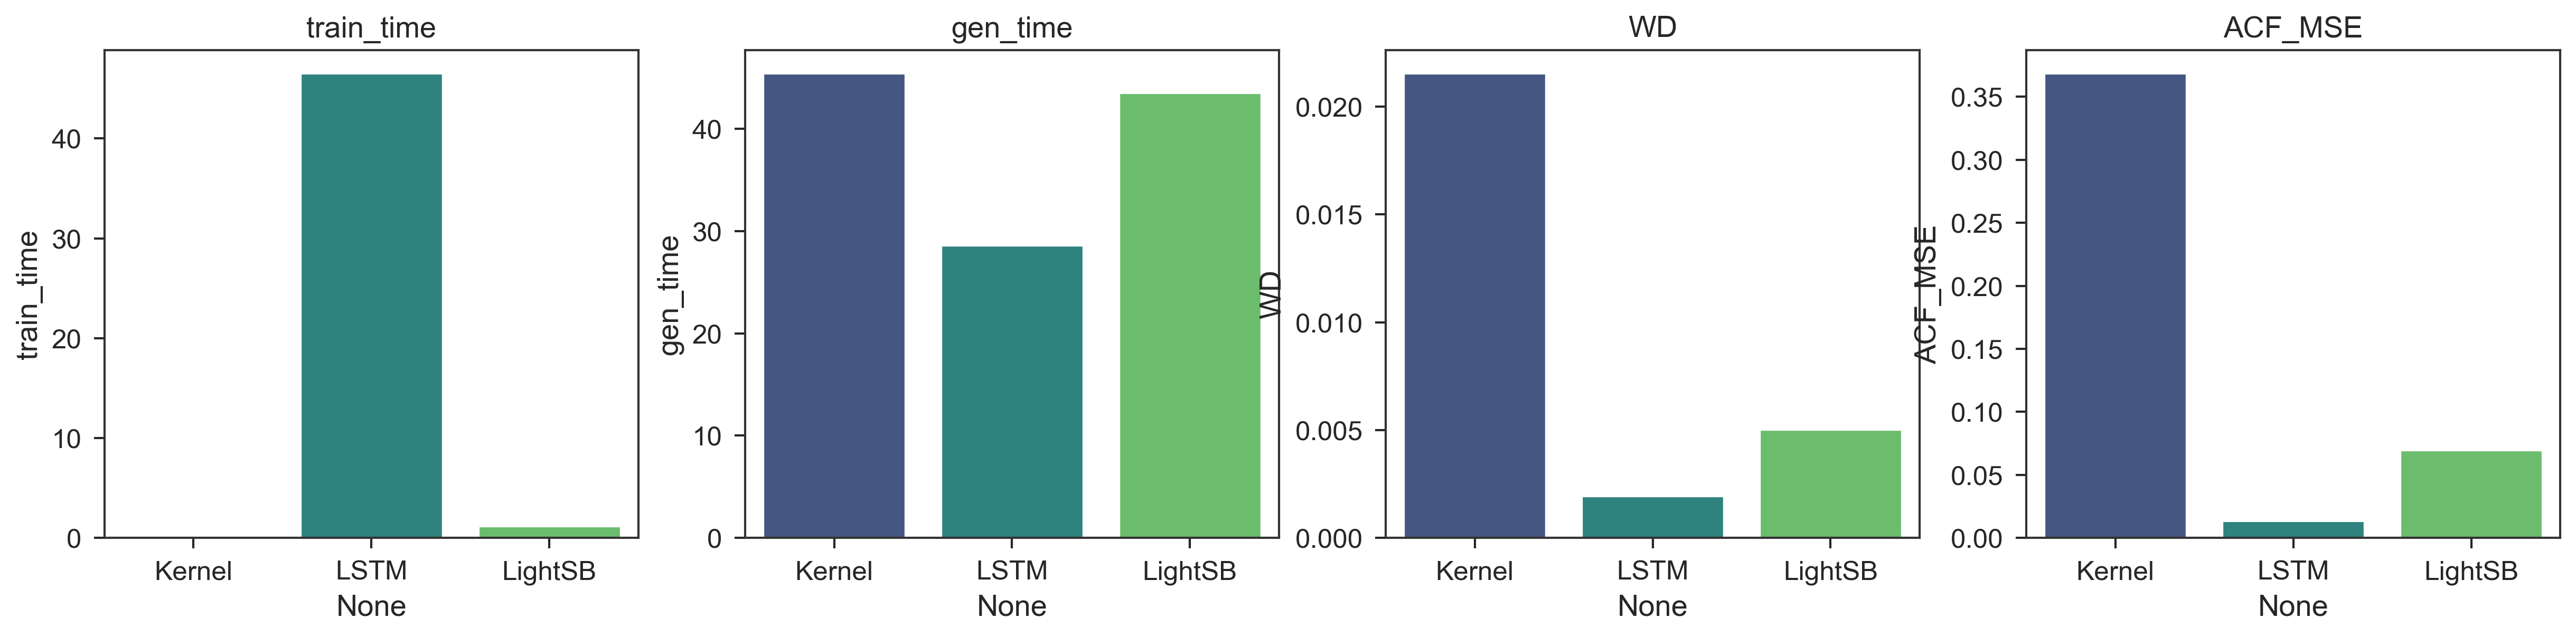

In [7]:
def calc_metrics(real, gen):
# WD: Distribution Distance
    wd = wasserstein_distance(real[:, -1, 0], gen[:, -1, 0])
# ACF MSE: Temporal Correlation Error
    acf_real = _calc_autocorr(real, 15)
    acf_gen = _calc_autocorr(gen, 15)
    acf_err = np.mean((acf_real - acf_gen)**2)
    return wd, acf_err

for k in results:
    wd, acf = calc_metrics(real_paths_subset, results[k]['paths'])
    results[k]['WD'] = wd
    results[k]['ACF_MSE'] = acf

df = pd.DataFrame(results).T[['train_time', 'gen_time', 'WD', 'ACF_MSE']]
print(df)

fig, ax = plt.subplots(1, 4, figsize=(20, 4))
for i, col in enumerate(df.columns):
    sns.barplot(x=df.index, y=df[col], ax=ax[i], palette='viridis')
    ax[i].set_title(col)
plt.show()

## 7. Final Comparison: Price Paths & Return Distribution

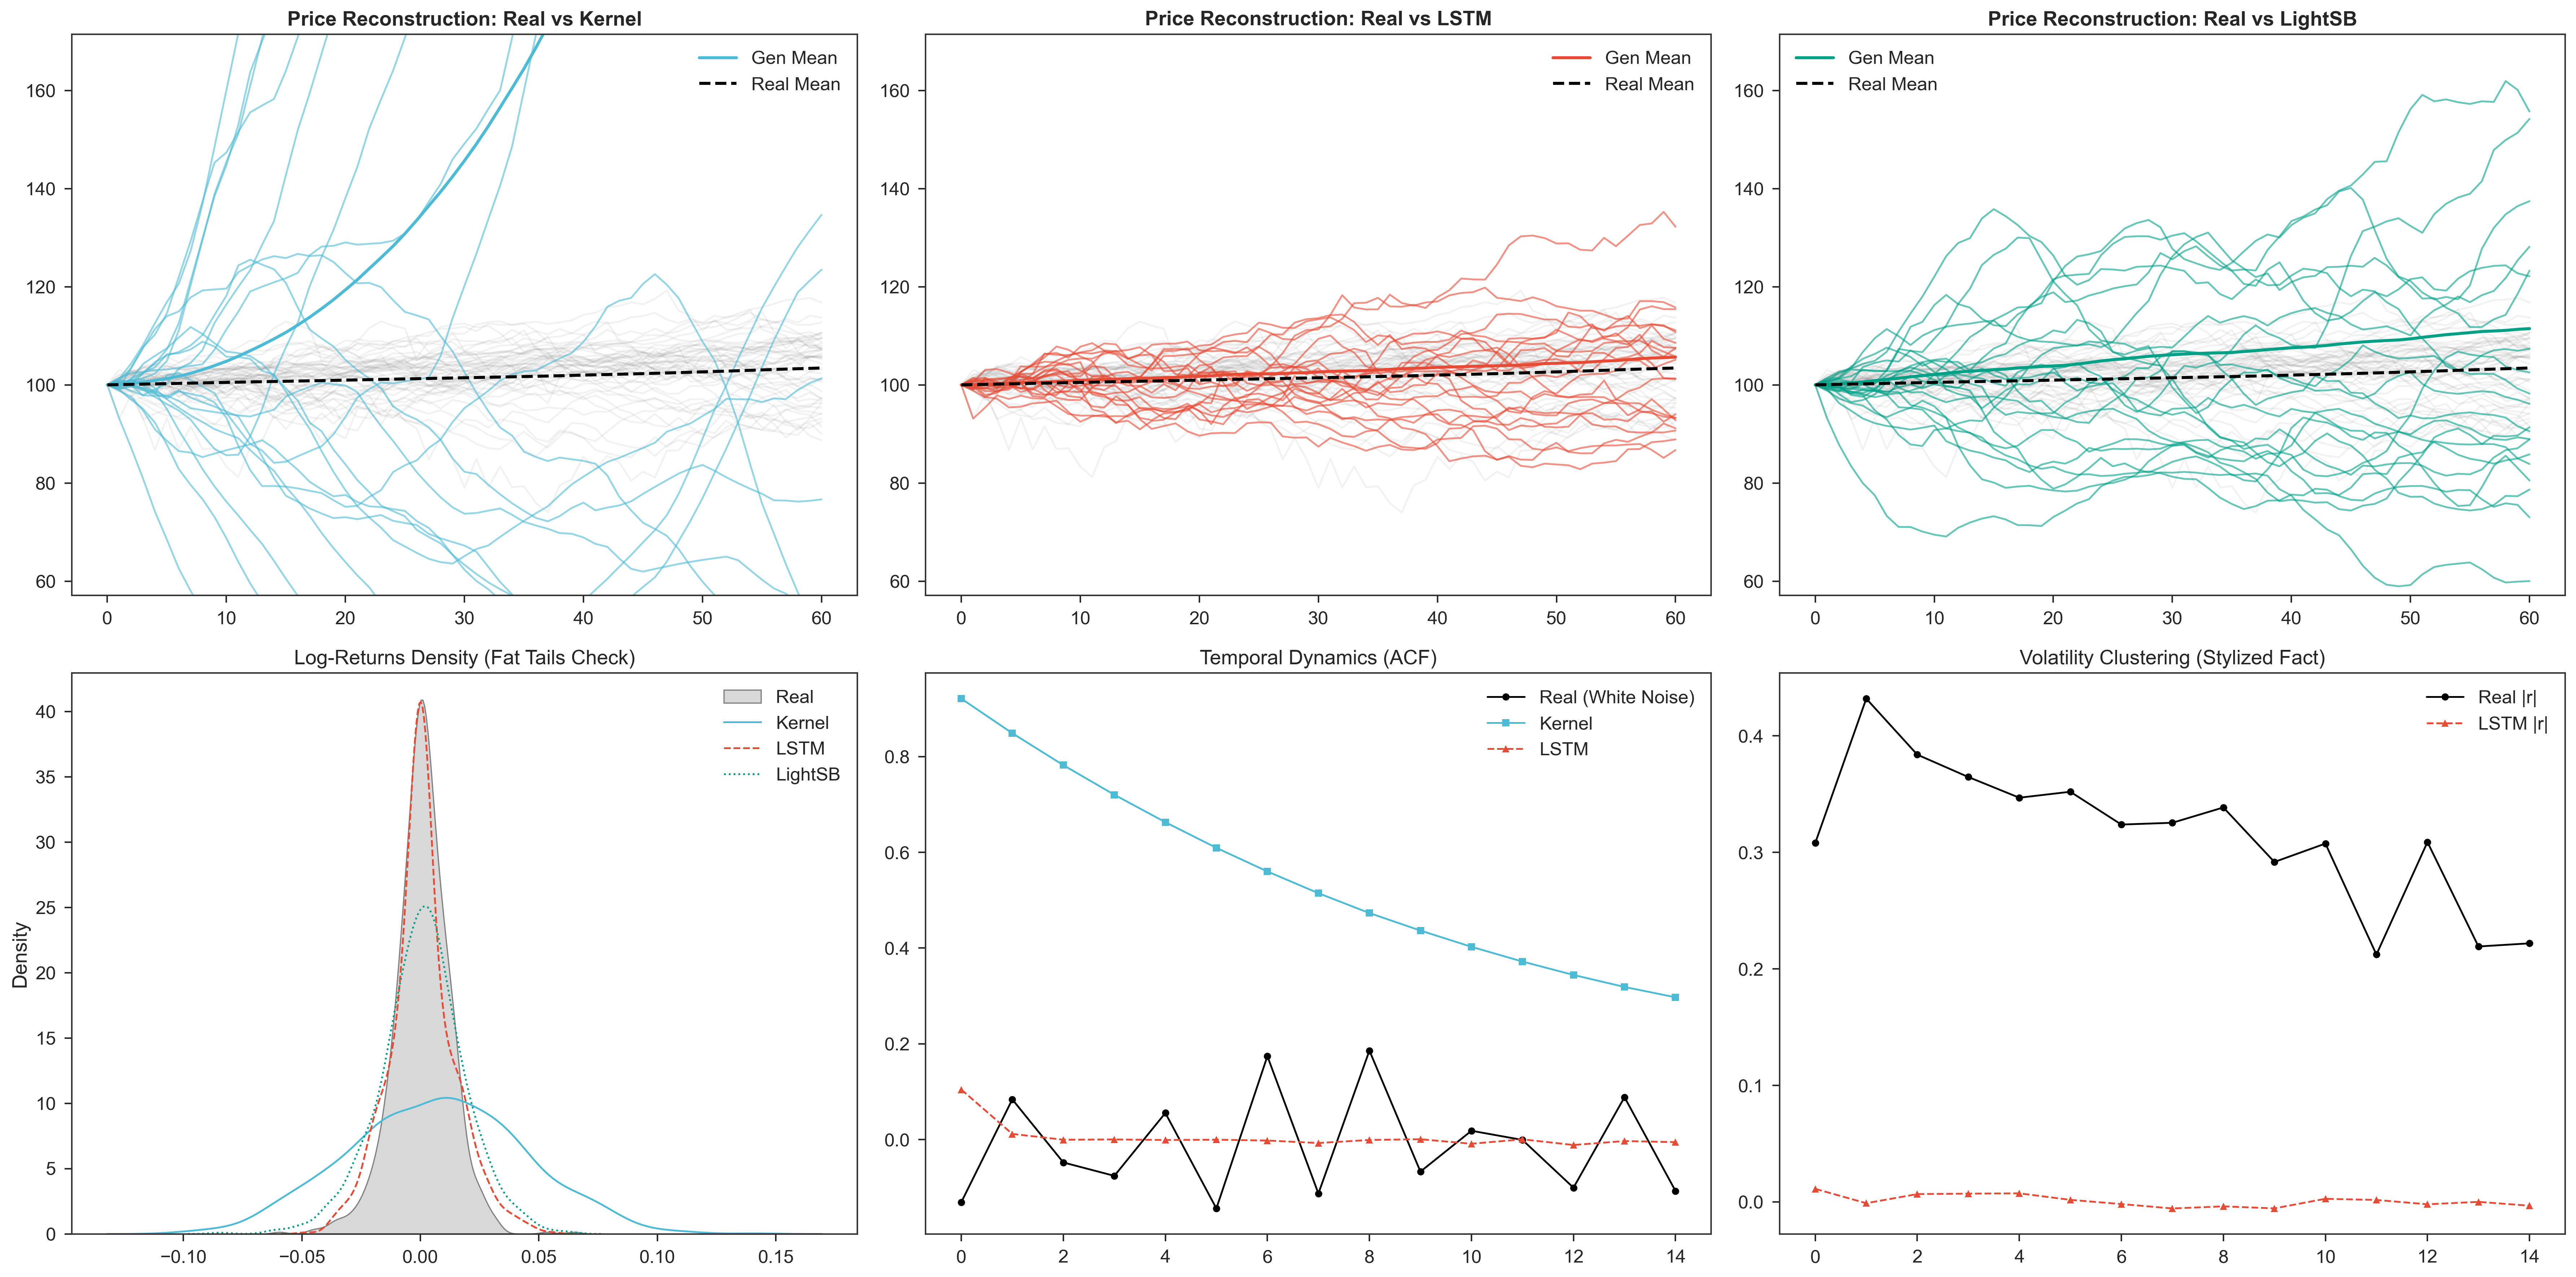

In [8]:
# Price Reconstruction
S0 = 100
price_real = reconstruct_prices(S0, real_paths_subset)
price_kernel = reconstruct_prices(S0, results['Kernel']['paths'])
price_lstm = reconstruct_prices(S0, results['LSTM']['paths'])
price_lsb = reconstruct_prices(S0, results['LightSB']['paths'])

fig, axes = plt.subplots(2, 3, figsize=(24, 12))

# Row 1: Price Path Comparison
pairs = [('Kernel', price_kernel, '#4DBBD5'), 
         ('LSTM', price_lstm, '#E64B35'), 
         ('LightSB', price_lsb, '#00A087')]

for i, (name, p_data, color) in enumerate(pairs):
    ax = axes[0, i]
# Background: Real Price
    ax.plot(price_real[:50, :, 0].T, color='gray', alpha=0.1)
# Foreground: Generated Price (Skip if NaN)
    if not np.isnan(p_data).any():
        ax.plot(p_data[:20, :, 0].T, color=color, alpha=0.6)
        ax.plot(np.mean(p_data, axis=0), color=color, linewidth=2, label='Gen Mean')
    
    ax.plot(np.mean(price_real, axis=0), 'k--', linewidth=2, label='Real Mean')
    ax.set_title(f"Price Reconstruction: Real vs {name}", fontweight='bold')
    ax.legend()
# Limit y-axis to prevent LightSB explosion from affecting observation
    ax.set_ylim(np.min(price_real)*0.8, np.max(price_real)*1.2)

# Row 2: Statistical Detail Indicators
# 2.1 Terminal Density
ax = axes[1, 0]
sns.kdeplot(real_paths_subset[:, -1, 0], ax=ax, color='gray', fill=True, alpha=0.3, label='Real')
sns.kdeplot(results['Kernel']['paths'][:, -1, 0], ax=ax, color='#4DBBD5', label='Kernel')
sns.kdeplot(results['LSTM']['paths'][:, -1, 0], ax=ax, color='#E64B35', linestyle='--', label='LSTM')
sns.kdeplot(results['LightSB']['paths'][:, -1, 0], ax=ax, color='#00A087', linestyle=':', label='LightSB')
ax.set_title("Log-Returns Density (Fat Tails Check)")
ax.legend()

# 2.2 Autocorrelation
ax = axes[1, 1]
lag = np.arange(15)
ax.plot(lag, _calc_autocorr(real_paths_subset, 15), 'k-o', label='Real (White Noise)')
ax.plot(lag, _calc_autocorr(results['Kernel']['paths'], 15), 's-', color='#4DBBD5', label='Kernel')
ax.plot(lag, _calc_autocorr(results['LSTM']['paths'], 15), '^--', color='#E64B35', label='LSTM')
ax.set_title("Temporal Dynamics (ACF)")
ax.legend()

# 2.3 Volatility Clustering (Abs Returns ACF)
ax = axes[1, 2]
ax.plot(lag, _calc_autocorr(np.abs(real_paths_subset), 15), 'k-o', label='Real |r|')
ax.plot(lag, _calc_autocorr(np.abs(results['LSTM']['paths']), 15), '^--', color='#E64B35', label='LSTM |r|')
ax.set_title("Volatility Clustering (Stylized Fact)")
ax.legend()

plt.tight_layout()
plt.show()